## 1) Setup and Imports
Load dependencies, project modules, and evaluation constants.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
)

from config import HEADS, CSV_FILE
from model import MultiHeadClassifier
from dataset import MultiHeadDataset

ENCODER_NAME = "mental/mental-bert-base-uncased"
MODEL_PATH = "best_model.pt"
SEED = 42
VALIDATION_SPLIT = 0.2
BATCH_SIZE = 16
DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

HEAD_NAMES = [name for name, _ in HEADS]
sns.set_theme(style="whitegrid")
print(f"Device: {DEVICE}")
print(f"Heads:  {HEAD_NAMES}")

/opt/miniconda3/envs/research-proj/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps
Heads:  ['A_adaptive', 'A_maladaptive', 'B-O_adaptive', 'B-O_maladaptive', 'B-S_adaptive', 'B-S_maladaptive', 'C-O_adaptive', 'C-O_maladaptive', 'C-S_adaptive', 'C-S_maladaptive', 'D_adaptive', 'D_maladaptive']


## 2) Load Model and Build Validation Predictions
Recreate the validation split with the same recipe as `trainer.py` (`random_split` + `torch.Generator().manual_seed(SEED)`, `SEED=42` = `SPLIT_SEED` in trainer), then load `best_model.pt` and collect per-head predictions and labels.

In [3]:
dataset = MultiHeadDataset(CSV_FILE, ENCODER_NAME)
val_size = int(len(dataset) * VALIDATION_SPLIT)
train_size = len(dataset) - val_size

split_generator = torch.Generator().manual_seed(SEED)
_, val_ds = random_split(dataset, [train_size, val_size], generator=split_generator)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE)

model = MultiHeadClassifier(ENCODER_NAME).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
model.eval()

all_preds = [[] for _ in HEADS]
all_labels = [[] for _ in HEADS]

with torch.no_grad():
    for batch in val_dl:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        logits = model(input_ids, attention_mask)
        for i, logit in enumerate(logits):
            preds = logit.argmax(dim=-1).cpu().numpy()
            truth = labels[:, i].cpu().numpy()
            all_preds[i].extend(preds)
            all_labels[i].extend(truth)

all_preds = [np.array(p) for p in all_preds]
all_labels = [np.array(l) for l in all_labels]
print(f"Collected predictions for {len(val_ds)} validation samples across {len(HEADS)} heads.")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 71737.97it/s]
BertModel LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

Collected predictions for 74 validation samples across 12 heads.


## 3) Per-Head Summary Table
Compute and display per-head accuracy, macro-F1, and weighted-F1 with a mean row.

In [ ]:
rows = []
for i, (head_name, _) in enumerate(HEADS):
    y_true, y_pred = all_labels[i], all_preds[i]
    rows.append({
        "Head": head_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted-F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    })

summary_df = pd.DataFrame(rows).set_index("Head")

mean_row = pd.DataFrame([{
    "Head": "MEAN",
    "Accuracy": summary_df["Accuracy"].mean(),
    "Macro-F1": summary_df["Macro-F1"].mean(),
    "Weighted-F1": summary_df["Weighted-F1"].mean(),
}]).set_index("Head")

summary_df = pd.concat([summary_df, mean_row])
summary_df.style.format("{:.3f}").set_properties(**{"font-weight": "bold"}, subset=pd.IndexSlice["MEAN", :])

,Accuracy,Macro-F1,Weighted-F1
Head,,,
A_adaptive,0.919,0.160,0.880
A_maladaptive,0.784,0.348,0.755
B-O_adaptive,0.784,0.497,0.768
B-O_maladaptive,0.865,0.309,0.802
B-S_adaptive,0.784,0.627,0.784
B-S_maladaptive,0.892,0.720,0.910
C-O_adaptive,0.838,0.527,0.807
C-O_maladaptive,0.811,0.523,0.792
C-S_adaptive,0.824,0.568,0.766


## 4) Metric Visualizations
Show separate charts for accuracy, macro-F1, and weighted-F1 across heads.

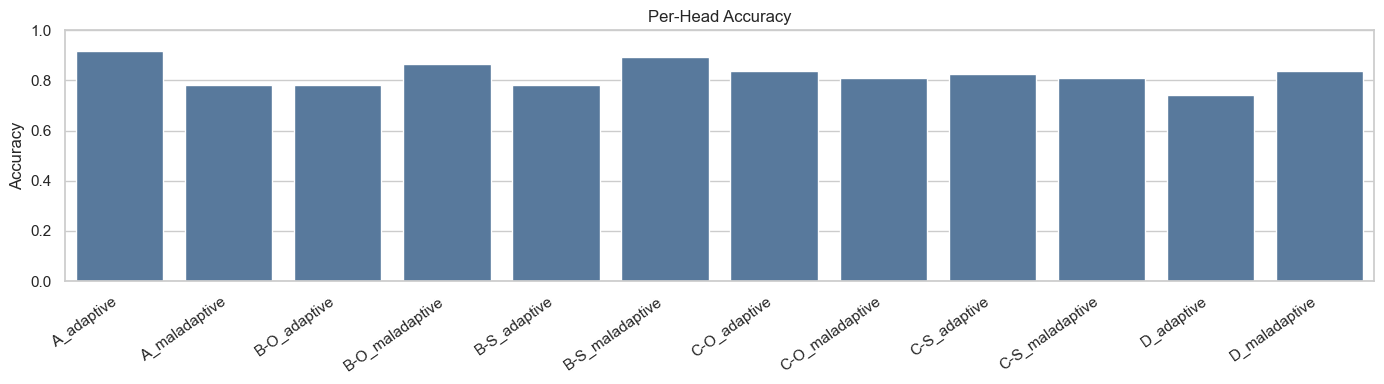

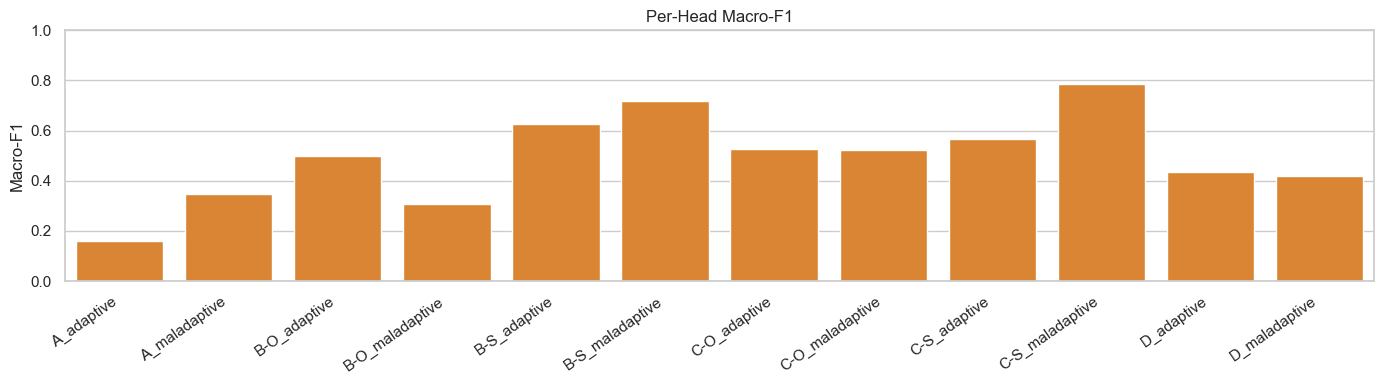

Mean Weighted-F1 across heads: 0.799


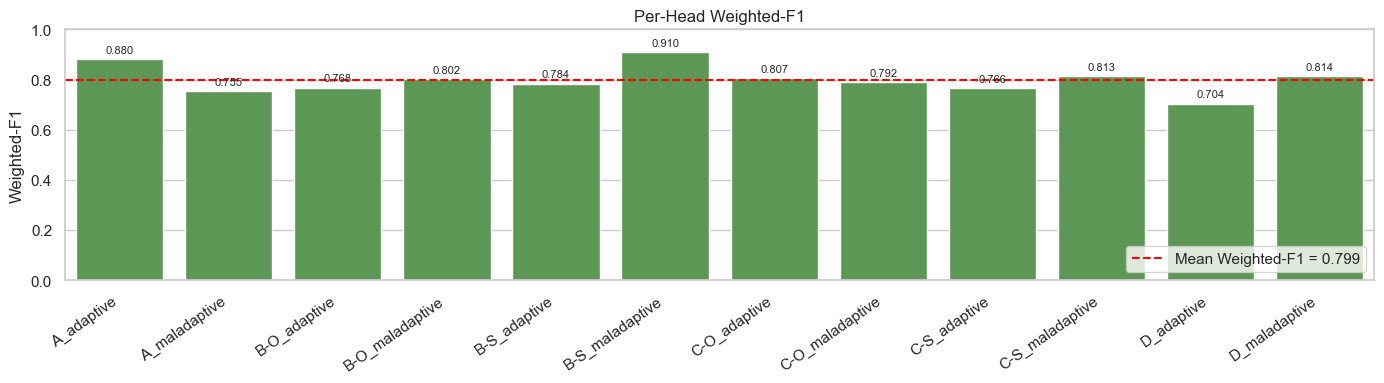

In [9]:
plot_base = summary_df.drop("MEAN").reset_index()

# Accuracy plot
fig, ax = plt.subplots(figsize=(14, 4))
sns.barplot(data=plot_base, x="Head", y="Accuracy", color="#4C78A8", ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_xlabel("")
ax.set_title("Per-Head Accuracy")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# Macro-F1 plot
fig, ax = plt.subplots(figsize=(14, 4))
sns.barplot(data=plot_base, x="Head", y="Macro-F1", color="#F58518", ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Macro-F1")
ax.set_xlabel("")
ax.set_title("Per-Head Macro-F1")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# Weighted-F1 plot with value labels and mean line
fig, ax = plt.subplots(figsize=(14, 4))
sns.barplot(data=plot_base, x="Head", y="Weighted-F1", color="#54A24B", ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Weighted-F1")
ax.set_xlabel("")
ax.set_title("Per-Head Weighted-F1")

mean_weighted_f1 = plot_base["Weighted-F1"].mean()
ax.axhline(mean_weighted_f1, color="red", linestyle="--", linewidth=1.5, label=f"Mean Weighted-F1 = {mean_weighted_f1:.3f}")
ax.legend(loc="lower right")

for patch, value in zip(ax.patches, plot_base["Weighted-F1"]):
    ax.annotate(
        f"{value:.3f}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        fontsize=8,
        xytext=(0, 3),
        textcoords="offset points",
    )

print(f"Mean Weighted-F1 across heads: {mean_weighted_f1:.3f}")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### Valence presence F1 (binary: head present vs absent)

For each of the 12 heads, we **ignore which non-zero class** was predicted. We only ask: did the model correctly predict **presence** (any non-zero label) vs **absent** (label 0)?

- **Per-head:** binary F1 with `positive = present` (true label ≠ 0).
- **Adaptive macro-F1:** mean of those binary F1s over the 6 adaptive heads.
- **Maladaptive macro-F1:** mean over the 6 maladaptive heads.
- **Overall:** mean of the two valence-level macros above.

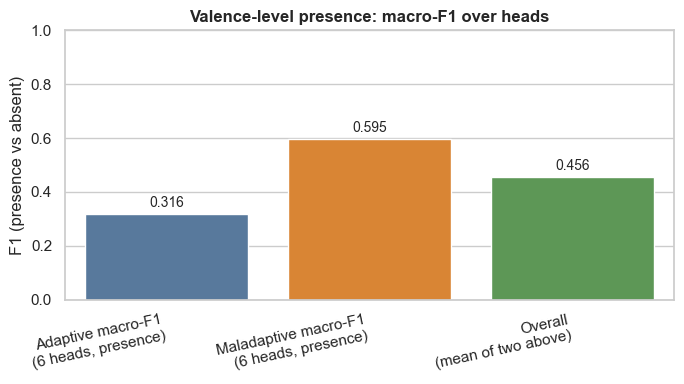

,Head,Valence,Presence F1
0,A_adaptive,adaptive,0.000000
1,B-O_adaptive,adaptive,0.651163
2,B-S_adaptive,adaptive,0.384615
3,C-O_adaptive,adaptive,0.142857
4,C-S_adaptive,adaptive,0.235294
5,D_adaptive,adaptive,0.484848
6,A_maladaptive,maladaptive,0.905660
7,B-O_maladaptive,maladaptive,0.000000
8,B-S_maladaptive,maladaptive,0.500000
9,C-O_maladaptive,maladaptive,0.727273


Adaptive macro-F1 (presence):    0.316
Maladaptive macro-F1 (presence): 0.595
Overall (mean of valence macros): 0.456


In [12]:
presence_rows = []
for i, (head_name, _) in enumerate(HEADS):
    y_true = (all_labels[i] != 0).astype(int)
    y_pred = (all_preds[i] != 0).astype(int)
    f1_pres = f1_score(y_true, y_pred, average="binary", pos_label=1, zero_division=0)
    valence = "adaptive" if head_name.endswith("_adaptive") else "maladaptive"
    presence_rows.append({"Head": head_name, "Valence": valence, "Presence F1": f1_pres})

presence_df = pd.DataFrame(presence_rows)

adaptive_presence_macro = presence_df.loc[presence_df["Valence"] == "adaptive", "Presence F1"].mean()
maladaptive_presence_macro = presence_df.loc[presence_df["Valence"] == "maladaptive", "Presence F1"].mean()
overall_valence_macro = (adaptive_presence_macro + maladaptive_presence_macro) / 2

agg_valence = pd.DataFrame({
    "Metric": [
        "Adaptive macro-F1\n(6 heads, presence)",
        "Maladaptive macro-F1\n(6 heads, presence)",
        "Overall\n(mean of two above)",
    ],
    "Score": [adaptive_presence_macro, maladaptive_presence_macro, overall_valence_macro],
})

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=agg_valence, x="Metric", y="Score", hue="Metric", palette=["#4C78A8", "#F58518", "#54A24B"], legend=False, ax=ax)
ax.set_ylim(0, 1)
ax.set_xlabel("")
ax.set_ylabel("F1 (presence vs absent)")
ax.set_title("Valence-level presence: macro-F1 over heads", fontweight="bold")
for patch, value in zip(ax.patches, agg_valence["Score"]):
    ax.annotate(
        f"{value:.3f}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points",
    )
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

display(presence_df.sort_values(["Valence", "Head"]).reset_index(drop=True))
print(f"Adaptive macro-F1 (presence):    {adaptive_presence_macro:.3f}")
print(f"Maladaptive macro-F1 (presence): {maladaptive_presence_macro:.3f}")
print(f"Overall (mean of valence macros): {overall_valence_macro:.3f}")

## 5) Detailed Per-Class Reports
Print precision, recall, F1-score, and support for every class in each head.

In [10]:
for i, (head_name, num_classes) in enumerate(HEADS):
    y_true, y_pred = all_labels[i], all_preds[i]
    print(f"{'=' * 60}")
    print(f"  {head_name}  ({num_classes} classes)")
    print(f"{'=' * 60}")
    print(classification_report(
        y_true, y_pred,
        labels=list(range(num_classes)),
        zero_division=0,
    ))
    print()

  A_adaptive  (8 classes)
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        68
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         0

    accuracy                           0.92        74
   macro avg       0.11      0.12      0.12        74
weighted avg       0.84      0.92      0.88        74


  A_maladaptive  (8 classes)
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        48
           1       0.42      0.62      0.50         8
           2       0.53      0.80      0.64        10
           3       0.00      0.00      0.00         0
           4       0.0

## 6) Confusion Matrix Heatmaps
Visual diagnostics for the larger multi-class heads.

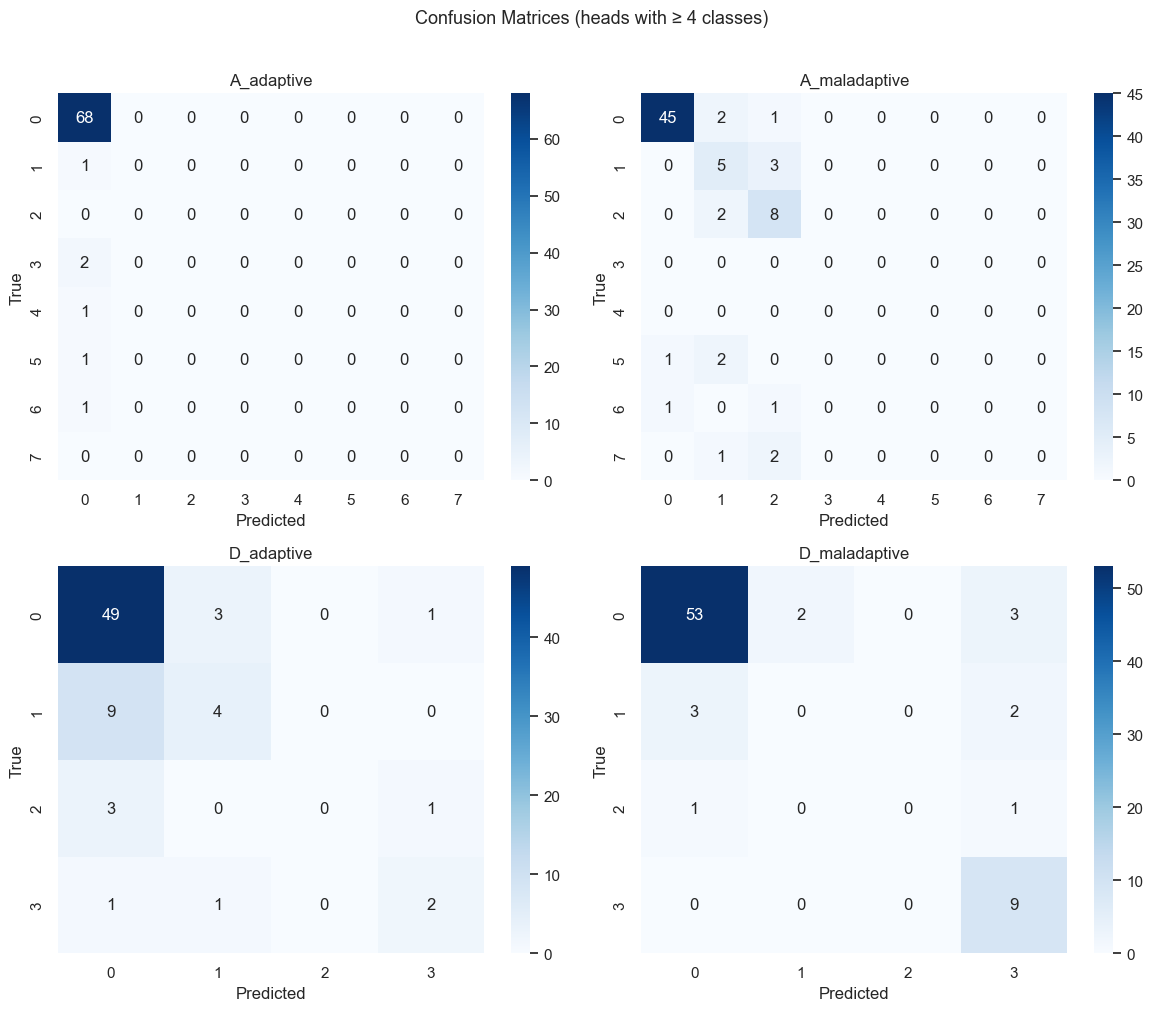

In [11]:
cm_heads = [(i, name, nc) for i, (name, nc) in enumerate(HEADS) if nc >= 4]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (head_idx, head_name, num_classes) in zip(axes, cm_heads):
    y_true, y_pred = all_labels[head_idx], all_preds[head_idx]
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=range(num_classes), yticklabels=range(num_classes))
    ax.set_title(head_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrices (heads with ≥ 4 classes)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 7) Overall Metric Summary
Print mean metrics across all heads for a quick final snapshot.

In [7]:
mean_acc = summary_df.loc[summary_df.index != "MEAN", "Accuracy"].mean()
mean_macro = summary_df.loc[summary_df.index != "MEAN", "Macro-F1"].mean()
mean_weighted = summary_df.loc[summary_df.index != "MEAN", "Weighted-F1"].mean()

print("=" * 40)
print("  OVERALL SUMMARY (mean across heads)")
print("=" * 40)
print(f"  Mean Accuracy:    {mean_acc:.3f}")
print(f"  Mean Macro-F1:    {mean_macro:.3f}")
print(f"  Mean Weighted-F1: {mean_weighted:.3f}")
print("=" * 40)

  OVERALL SUMMARY (mean across heads)
  Mean Accuracy:    0.824
  Mean Macro-F1:    0.493
  Mean Weighted-F1: 0.799
